In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
station = pd.read_csv('data/AQI/stations.csv')
station_hour = pd.read_csv('data/AQI/station_hour.csv',parse_dates=['Datetime'])

/tmp/ipykernel_1782866/1199967659.py:2: DtypeWarning: Columns (0: AQI_Bucket) have mixed types. Specify dtype option on import or set low_memory=False.
  station_hour = pd.read_csv('data/AQI/station_hour.csv',parse_dates=['Datetime'])


In [4]:
station.head()

,StationId,StationName,City,State,Status
0,AP001,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
1,AP002,"Anand Kala Kshetram, Rajamahendravaram - APPCB",Rajamahendravaram,Andhra Pradesh,NaN
2,AP003,"Tirumala, Tirupati - APPCB",Tirupati,Andhra Pradesh,NaN
3,AP004,"PWD Grounds, Vijayawada - APPCB",Vijayawada,Andhra Pradesh,NaN
4,AP005,"GVM Corporation, Visakhapatnam - APPCB",Visakhapatnam,Andhra Pradesh,Active


In [5]:
station_hour.head()

,StationId,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,AP001,2017-11-24 17:00:00,60.50,98.00,2.35,30.80,18.25,8.50,0.1,11.85,126.40,0.1,6.10,0.10,NaN,NaN
1,AP001,2017-11-24 18:00:00,65.50,111.25,2.70,24.20,15.07,9.77,0.1,13.17,117.12,0.1,6.25,0.15,NaN,NaN
2,AP001,2017-11-24 19:00:00,80.00,132.00,2.10,25.18,15.15,12.02,0.1,12.08,98.98,0.2,5.98,0.18,NaN,NaN
3,AP001,2017-11-24 20:00:00,81.50,133.25,1.95,16.25,10.23,11.58,0.1,10.47,112.20,0.2,6.72,0.10,NaN,NaN
4,AP001,2017-11-24 21:00:00,75.25,116.00,1.43,17.48,10.43,12.03,0.1,9.12,106.35,0.2,5.75,0.08,NaN,NaN


In [6]:
merged_df = pd.merge(station_hour, station, on='StationId', how='left')
merged_df.head()

,StationId,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,StationName,City,State,Status
0,AP001,2017-11-24 17:00:00,60.50,98.00,2.35,30.80,18.25,8.50,0.1,11.85,126.40,0.1,6.10,0.10,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
1,AP001,2017-11-24 18:00:00,65.50,111.25,2.70,24.20,15.07,9.77,0.1,13.17,117.12,0.1,6.25,0.15,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
2,AP001,2017-11-24 19:00:00,80.00,132.00,2.10,25.18,15.15,12.02,0.1,12.08,98.98,0.2,5.98,0.18,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
3,AP001,2017-11-24 20:00:00,81.50,133.25,1.95,16.25,10.23,11.58,0.1,10.47,112.20,0.2,6.72,0.10,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
4,AP001,2017-11-24 21:00:00,75.25,116.00,1.43,17.48,10.43,12.03,0.1,9.12,106.35,0.2,5.75,0.08,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active


In [7]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2589083 entries, 0 to 2589082
Data columns (total 20 columns):
 #   Column       Dtype         
---  ------       -----         
 0   StationId    str           
 1   Datetime     datetime64[us]
 2   PM2.5        float64       
 3   PM10         float64       
 4   NO           float64       
 5   NO2          float64       
 6   NOx          float64       
 7   NH3          float64       
 8   CO           float64       
 9   SO2          float64       
 10  O3           float64       
 11  Benzene      float64       
 12  Toluene      float64       
 13  Xylene       float64       
 14  AQI          float64       
 15  AQI_Bucket   str           
 16  StationName  str           
 17  City         str           
 18  State        str           
 19  Status       str           
dtypes: datetime64[us](1), float64(13), str(6)
memory usage: 395.1 MB


In [8]:
merged_df.describe()

,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,2589083,1.941394e+06,1.469831e+06,2.035372e+06,2.060110e+06,2.098275e+06,1.352465e+06,2.089781e+06,1.846346e+06,1.863110e+06,1.727504e+06,1.546717e+06,513979.000000,2.018893e+06
mean,2018-08-17 09:52:35.777856,8.086481e+01,1.584839e+02,2.278825e+01,3.523689e+01,4.055115e+01,2.870856e+01,1.502366e+00,1.211602e+01,3.806408e+01,3.305493e+00,1.490266e+01,2.448881,1.801730e+02
min,2015-01-01 01:00:00,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,0.000000e+00,1.000000e-02,0.000000e+00,1.000000e-02,1.000000e-02,0.000000e+00,0.000000e+00,0.000000,5.000000e+00
25%,2017-10-13 20:00:00,2.816000e+01,6.400000e+01,3.050000e+00,1.310000e+01,1.135000e+01,1.123000e+01,4.100000e-01,4.250000e+00,1.102000e+01,8.000000e-02,3.400000e-01,0.000000,8.400000e+01
50%,2018-12-02 06:00:00,5.259000e+01,1.162500e+02,7.150000e+00,2.479000e+01,2.286000e+01,2.235000e+01,8.000000e-01,8.250000e+00,2.475000e+01,9.600000e-01,3.400000e+00,0.200000,1.310000e+02
75%,2019-10-15 06:00:00,9.774000e+01,2.040000e+02,1.858000e+01,4.548000e+01,4.570000e+01,3.778000e+01,1.380000e+00,1.453000e+01,4.953000e+01,3.230000e+00,1.510000e+01,1.830000,2.590000e+02
max,2020-07-01 00:00:00,1.000000e+03,1.000000e+03,5.000000e+02,4.999900e+02,5.000000e+02,4.999700e+02,4.985700e+02,1.999600e+02,9.970000e+02,4.980700e+02,4.999900e+02,499.990000,3.133000e+03
std,NaN,8.947618e+01,1.397883e+02,4.846146e+01,3.497508e+01,5.590894e+01,2.753244e+01,6.292445e+00,1.467385e+01,4.710653e+01,1.214053e+01,3.329729e+01,8.973470,1.404095e+02


In [9]:
merged_df.columns

Index(['StationId', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
       'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket',
       'StationName', 'City', 'State', 'Status'],
      dtype='str')

*Since you already saw huge missing percentages (40–80%), zeros are very likely sensor missing readings, so converting them to NaN is the correct approach.*

In [10]:
pollutants = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
       'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']

for col in pollutants:
    print(f"{col} - Zeros Values: {(merged_df[col] == 0).sum()}")

PM2.5 - Zeros Values: 0
PM10 - Zeros Values: 0
NO - Zeros Values: 0
NO2 - Zeros Values: 0
NOx - Zeros Values: 117924
NH3 - Zeros Values: 0
CO - Zeros Values: 181502
SO2 - Zeros Values: 0
O3 - Zeros Values: 0
Benzene - Zeros Values: 392342
Toluene - Zeros Values: 312987
Xylene - Zeros Values: 208359


*We are converting the zeros to nan,using Time series Interpolation best for hourly data*

In [11]:
for col in pollutants:
    merged_df[col] = merged_df[col].replace(0, np.nan)

In [12]:
for col in pollutants:
    print(f"{col} - Zero Values: {(merged_df[col] == 0).sum()}")

PM2.5 - Zero Values: 0
PM10 - Zero Values: 0
NO - Zero Values: 0
NO2 - Zero Values: 0
NOx - Zero Values: 0
NH3 - Zero Values: 0
CO - Zero Values: 0
SO2 - Zero Values: 0
O3 - Zero Values: 0
Benzene - Zero Values: 0
Toluene - Zero Values: 0
Xylene - Zero Values: 0


In [13]:
for col in pollutants:
    print(f"{col} - Missing Values: {merged_df[col].isna().mean()*100:.2f}%")

PM2.5 - Missing Values: 25.02%
PM10 - Missing Values: 43.23%
NO - Missing Values: 21.39%
NO2 - Missing Values: 20.43%
NOx - Missing Values: 23.51%
NH3 - Missing Values: 47.76%
CO - Missing Values: 26.30%
SO2 - Missing Values: 28.69%
O3 - Missing Values: 28.04%
Benzene - Missing Values: 48.43%
Toluene - Missing Values: 52.35%
Xylene - Missing Values: 88.20%


In [14]:
station_hour.shape

(2589083, 16)

In [15]:
merged_df[
    merged_df[['AQI','PM2.5','PM10']].isnull().all(axis=1)
].shape

(495557, 20)

In [16]:
merged_df = merged_df.dropna(
    subset=['AQI','PM2.5','PM10'],
    how='all'
)

In [17]:
merged_df.shape

(2093526, 20)

In [18]:
for col in pollutants:
    print(f"{col} - Missing Values: {merged_df[col].isna().mean()*100:.2f}%")

PM2.5 - Missing Values: 7.27%
PM10 - Missing Values: 29.79%
NO - Missing Values: 6.52%
NO2 - Missing Values: 5.26%
NOx - Missing Values: 9.93%
NH3 - Missing Values: 36.87%
CO - Missing Values: 11.41%
SO2 - Missing Values: 14.99%
O3 - Missing Values: 14.25%
Benzene - Missing Values: 39.08%
Toluene - Missing Values: 43.42%
Xylene - Missing Values: 85.72%


In [19]:
merged_df['AQI'].isna().mean()*100

np.float64(3.5649425896788483)

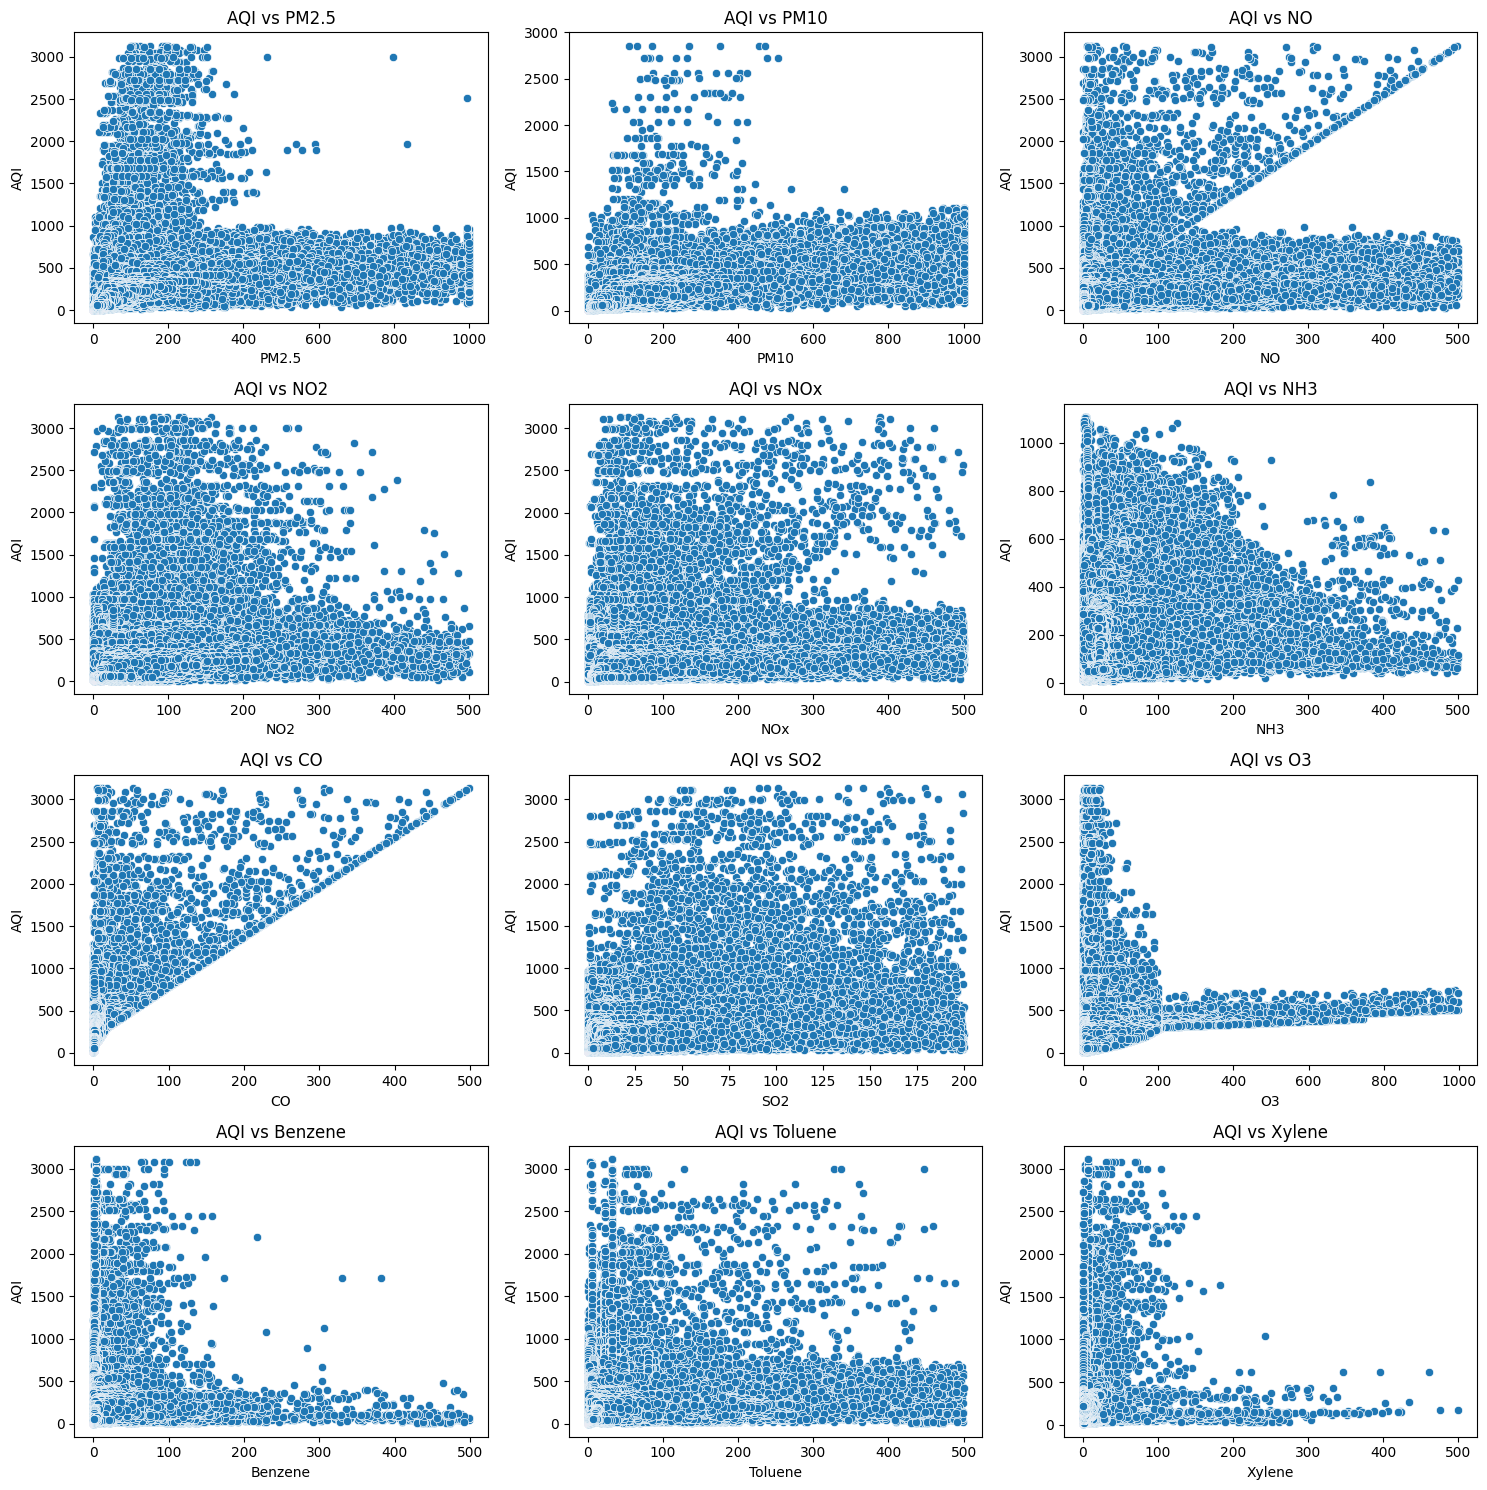

In [20]:
fig , ax = plt.subplots(4,3,figsize=(15,15))

for i , col in enumerate(pollutants):
    rows = i // 3
    cols = i % 3
    sns.scatterplot(x=col,y = 'AQI',data=merged_df,ax=ax[rows,cols])
    ax[rows,cols].set_title(f"AQI vs {col}")

plt.tight_layout()
plt.show()

In [21]:
# Dropping Xylene 85% null values present.

merged_df = merged_df.drop(columns=['Xylene'])
merged_df.head()

,StationId,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket,StationName,City,State,Status
0,AP001,2017-11-24 17:00:00,60.50,98.00,2.35,30.80,18.25,8.50,0.1,11.85,126.40,0.1,6.10,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
1,AP001,2017-11-24 18:00:00,65.50,111.25,2.70,24.20,15.07,9.77,0.1,13.17,117.12,0.1,6.25,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
2,AP001,2017-11-24 19:00:00,80.00,132.00,2.10,25.18,15.15,12.02,0.1,12.08,98.98,0.2,5.98,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
3,AP001,2017-11-24 20:00:00,81.50,133.25,1.95,16.25,10.23,11.58,0.1,10.47,112.20,0.2,6.72,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
4,AP001,2017-11-24 21:00:00,75.25,116.00,1.43,17.48,10.43,12.03,0.1,9.12,106.35,0.2,5.75,NaN,NaN,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active


In [22]:
pollutants.remove('Xylene')

In [23]:
pollutants.append('AQI')

In [24]:
# time interpolation

merged_df = merged_df.sort_values(['StationId','Datetime'])

merged_df = merged_df.set_index('Datetime')

for col in pollutants:
    merged_df[col] = merged_df.groupby('StationId')[col].transform(
        lambda x: x.interpolate(method='time')
    )

merged_df.reset_index(inplace=True)

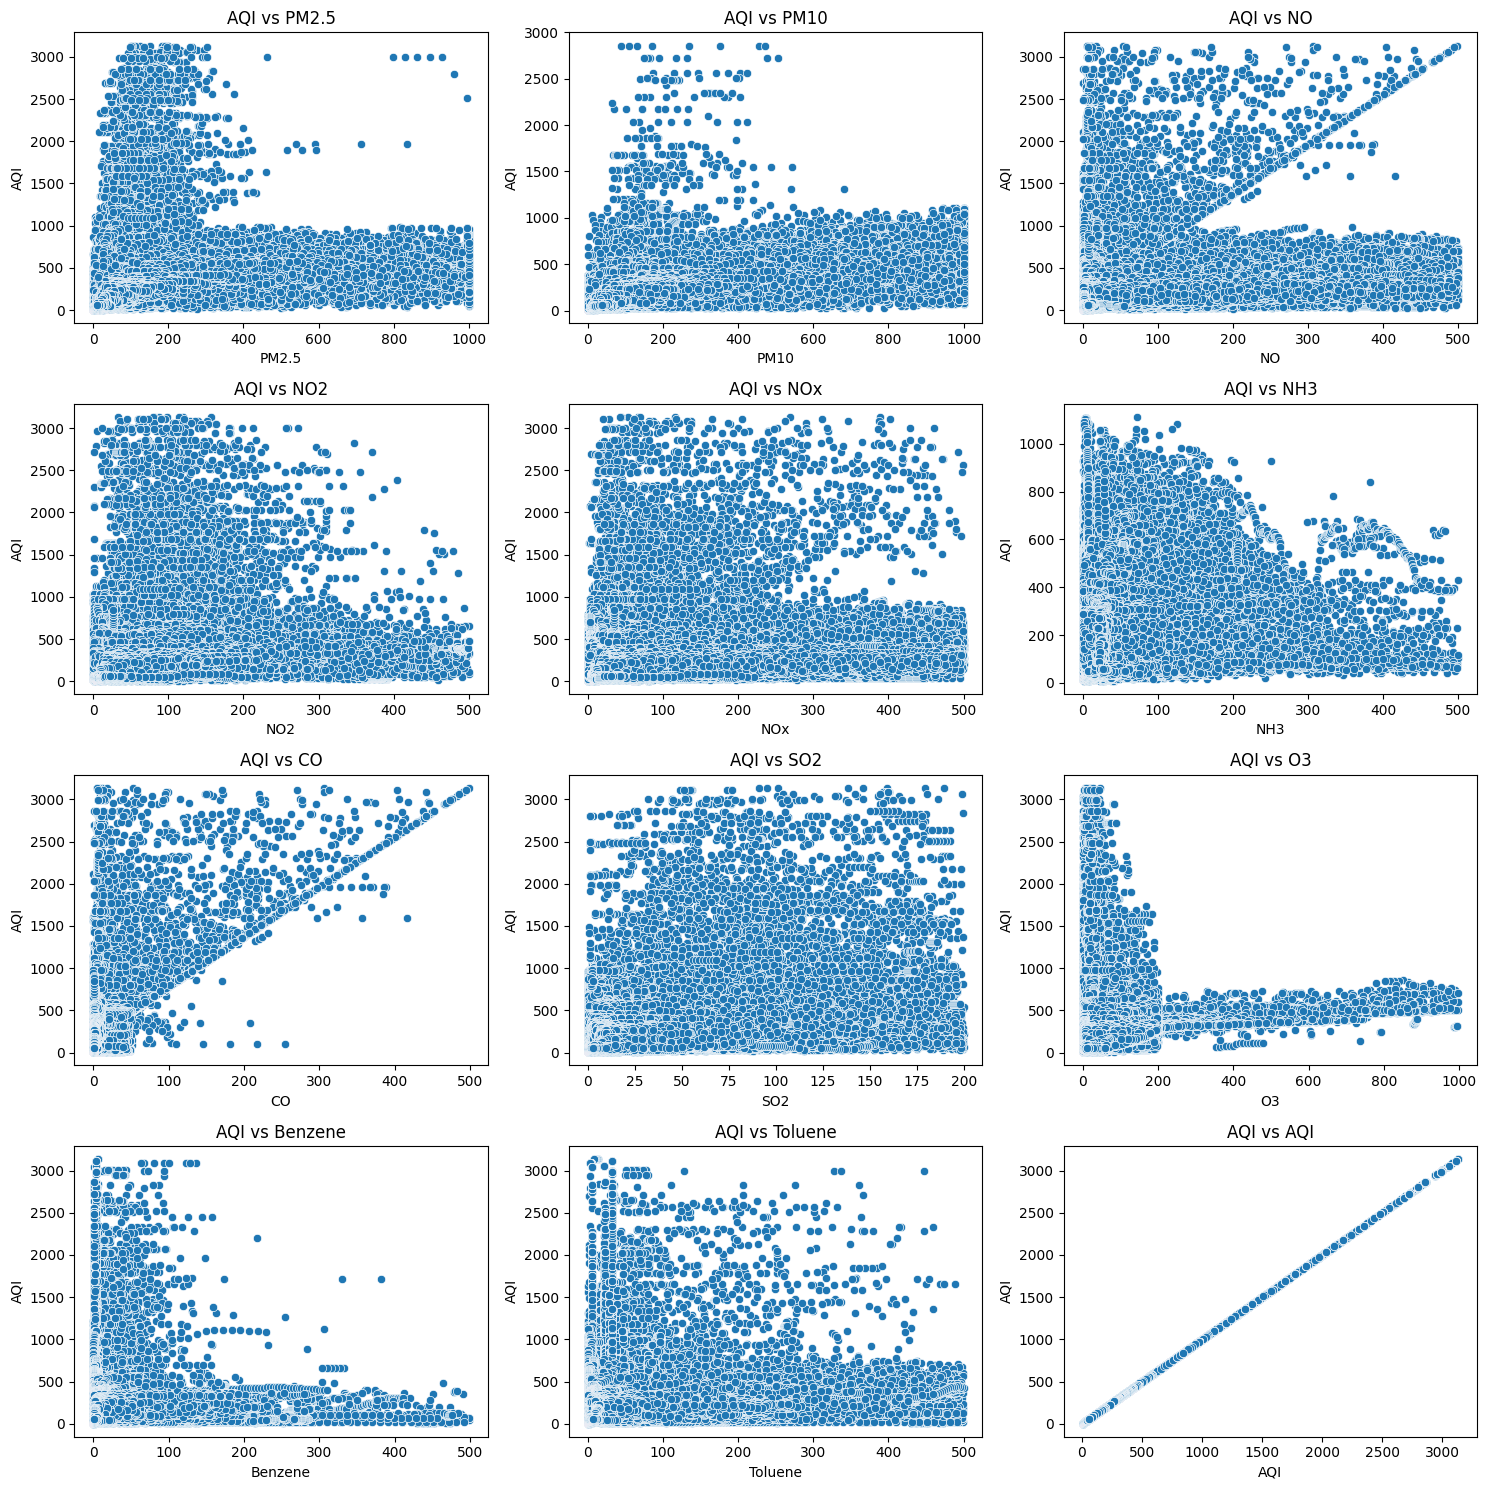

In [25]:
fig , ax = plt.subplots(4,3,figsize=(15,15))

for i , col in enumerate(pollutants):
    rows = i // 3
    cols = i % 3
    sns.scatterplot(x=col,y = 'AQI',data=merged_df,ax=ax[rows,cols])
    ax[rows,cols].set_title(f"AQI vs {col}")

plt.tight_layout()
plt.show()

In [26]:
merged_df[pollutants].isnull().mean().mean()* 100

np.float64(10.502150439020102)

*Instead of dropping I am using froward/backward filling , some of columns having more than 10% , so it will be better*

In [27]:
# forward/back fill
for col in pollutants:
    merged_df[col] = merged_df.groupby('StationId')[col].transform(
        lambda x: x.ffill().bfill()
    )

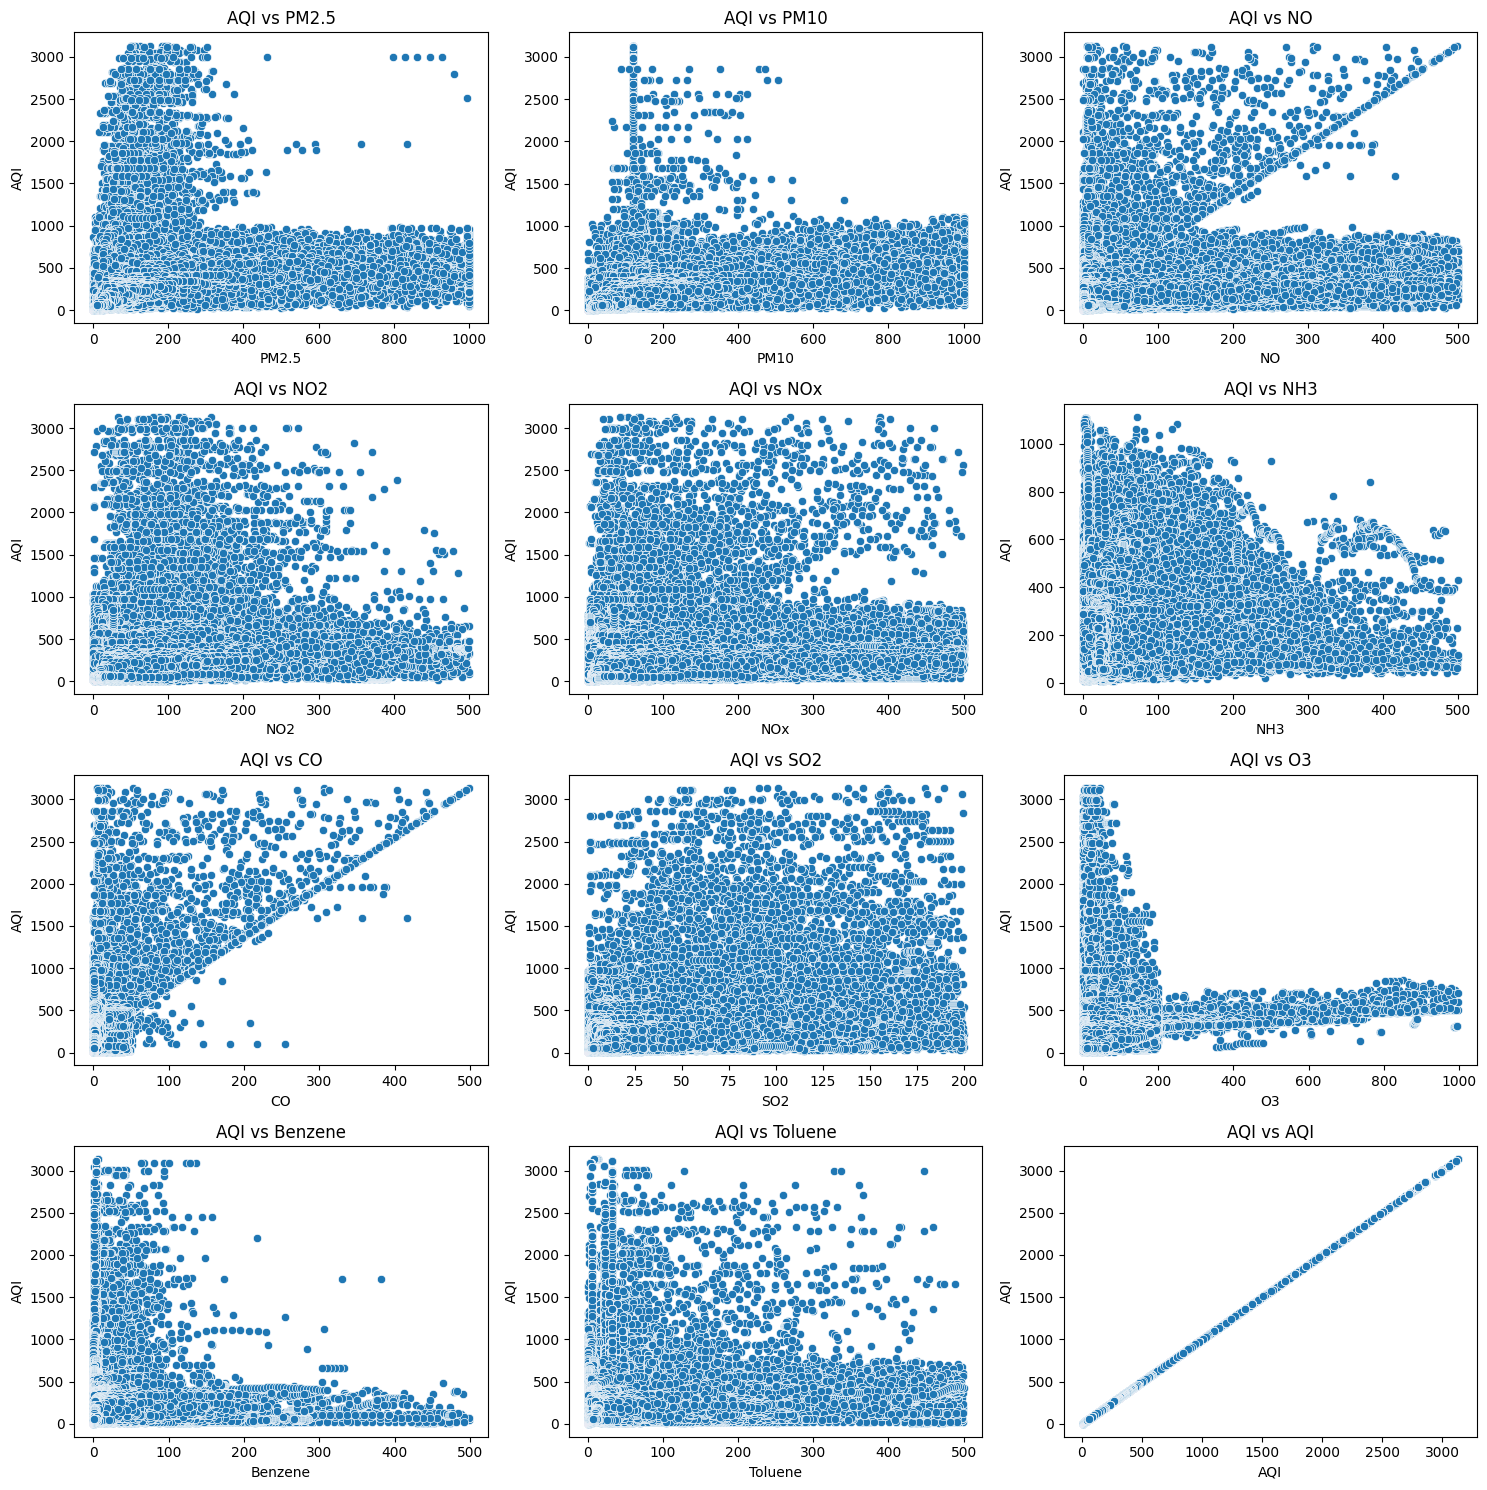

In [28]:
fig , ax = plt.subplots(4,3,figsize=(15,15))

for i , col in enumerate(pollutants):
    rows = i // 3
    cols = i % 3
    sns.scatterplot(x=col,y = 'AQI',data=merged_df,ax=ax[rows,cols])
    ax[rows,cols].set_title(f"AQI vs {col}")

plt.tight_layout()
plt.show()

In [29]:
merged_df[pollutants].isnull().mean().mean()* 100

np.float64(9.72155747448722)

*We improved only .5% only , not good but its ok, better than losing information, Now remaining values I tried to filed with median but distribution is affected , so I am removing it.*

In [30]:
merged_df['Hour'] = merged_df['Datetime'].dt.hour

In [31]:
# Station + Hour median
merged_df[pollutants] = merged_df.groupby(
    ['StationId','Hour']
)[pollutants].transform(lambda x: x.fillna(x.median()))

In [32]:
merged_df[pollutants].isnull().mean().mean()* 100

np.float64(9.72155747448722)

In [33]:
merged_df[pollutants] = merged_df.groupby(
    'StationId'
)[pollutants].transform(lambda x: x.fillna(x.median()))

In [34]:
merged_df[pollutants].isnull().mean().mean()* 100

np.float64(9.72155747448722)

In [35]:
merged_df[pollutants] = merged_df[pollutants].fillna(merged_df[pollutants].median())

In [36]:
merged_df[pollutants].isnull().mean().mean()* 100

np.float64(0.0)

In [37]:
merged_df.shape

(2093526, 20)

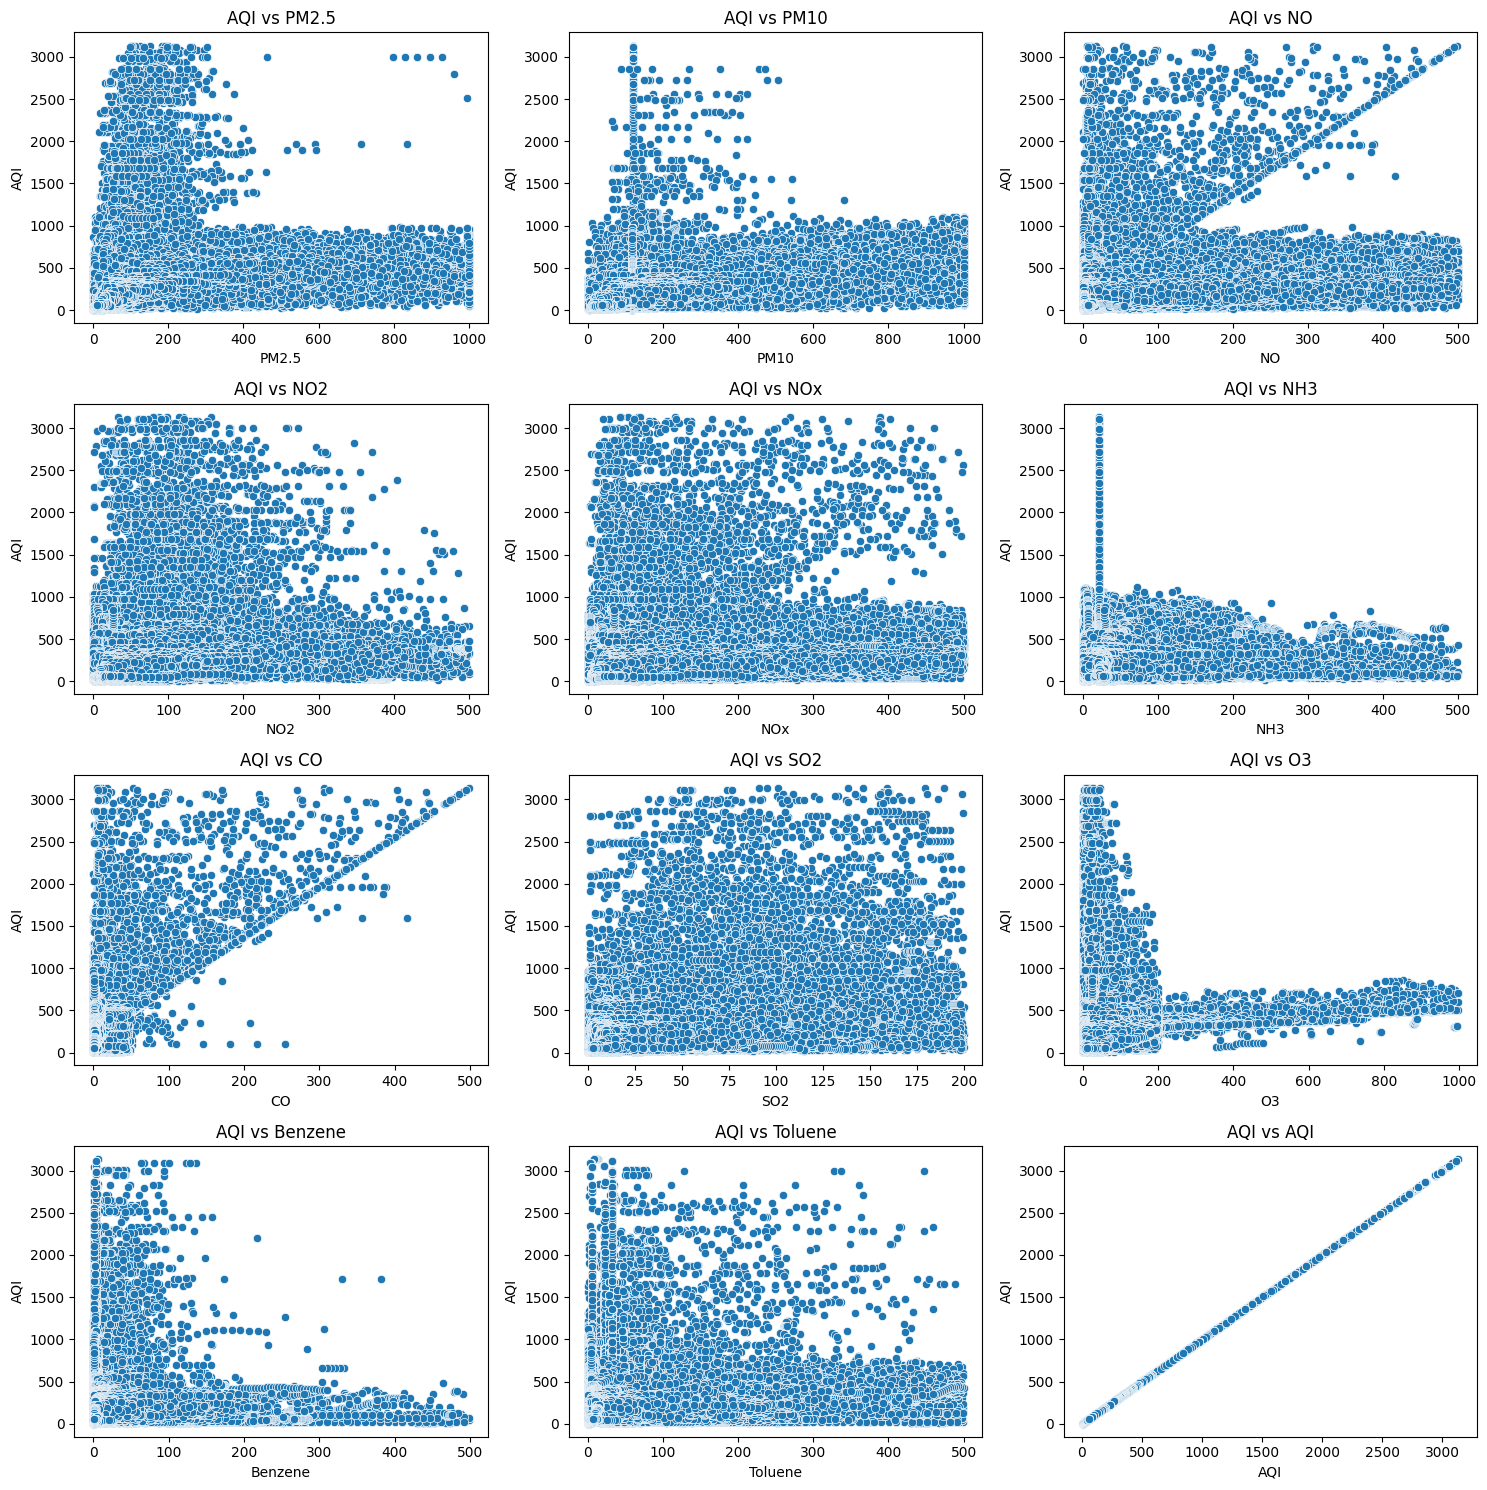

In [38]:
fig , ax = plt.subplots(4,3,figsize=(15,15))

for i , col in enumerate(pollutants):
    rows = i // 3
    cols = i % 3
    sns.scatterplot(x=col,y = 'AQI',data=merged_df,ax=ax[rows,cols])
    ax[rows,cols].set_title(f"AQI vs {col}")

plt.tight_layout()
plt.show()

In [39]:
merged_df.isnull().sum()

Datetime           0
StationId          0
PM2.5              0
PM10               0
NO                 0
NO2                0
NOx                0
NH3                0
CO                 0
SO2                0
O3                 0
Benzene            0
Toluene            0
AQI                0
AQI_Bucket     74633
StationName        0
City               0
State              0
Status          7396
Hour               0
dtype: int64

In [40]:
bins = [0, 50, 100, 200, 300, 400, float('inf')]

labels = [
    'Good',
    'Satisfactory',
    'Moderate',
    'Poor',
    'Very Poor',
    'Severe'
]

merged_df['AQI_Bucket'] = merged_df['AQI_Bucket'].fillna(
    pd.cut(merged_df['AQI'], bins=bins, labels=labels)
)

In [41]:
pd.crosstab(
    pd.cut(merged_df['AQI'], bins=bins, labels=labels),
    merged_df['AQI_Bucket']
)

AQI_Bucket,Good,Moderate,Poor,Satisfactory,Severe,Very Poor
AQI,,,,,,
Good,157809,0,0,0,0,0
Satisfactory,0,0,0,549435,0,0
Moderate,0,697580,0,0,0,0
Poor,0,0,248371,0,0,0
Very Poor,0,0,0,0,0,315542
Severe,0,0,0,0,124789,0


In [42]:
merged_df.isnull().sum()

Datetime          0
StationId         0
PM2.5             0
PM10              0
NO                0
NO2               0
NOx               0
NH3               0
CO                0
SO2               0
O3                0
Benzene           0
Toluene           0
AQI               0
AQI_Bucket        0
StationName       0
City              0
State             0
Status         7396
Hour              0
dtype: int64

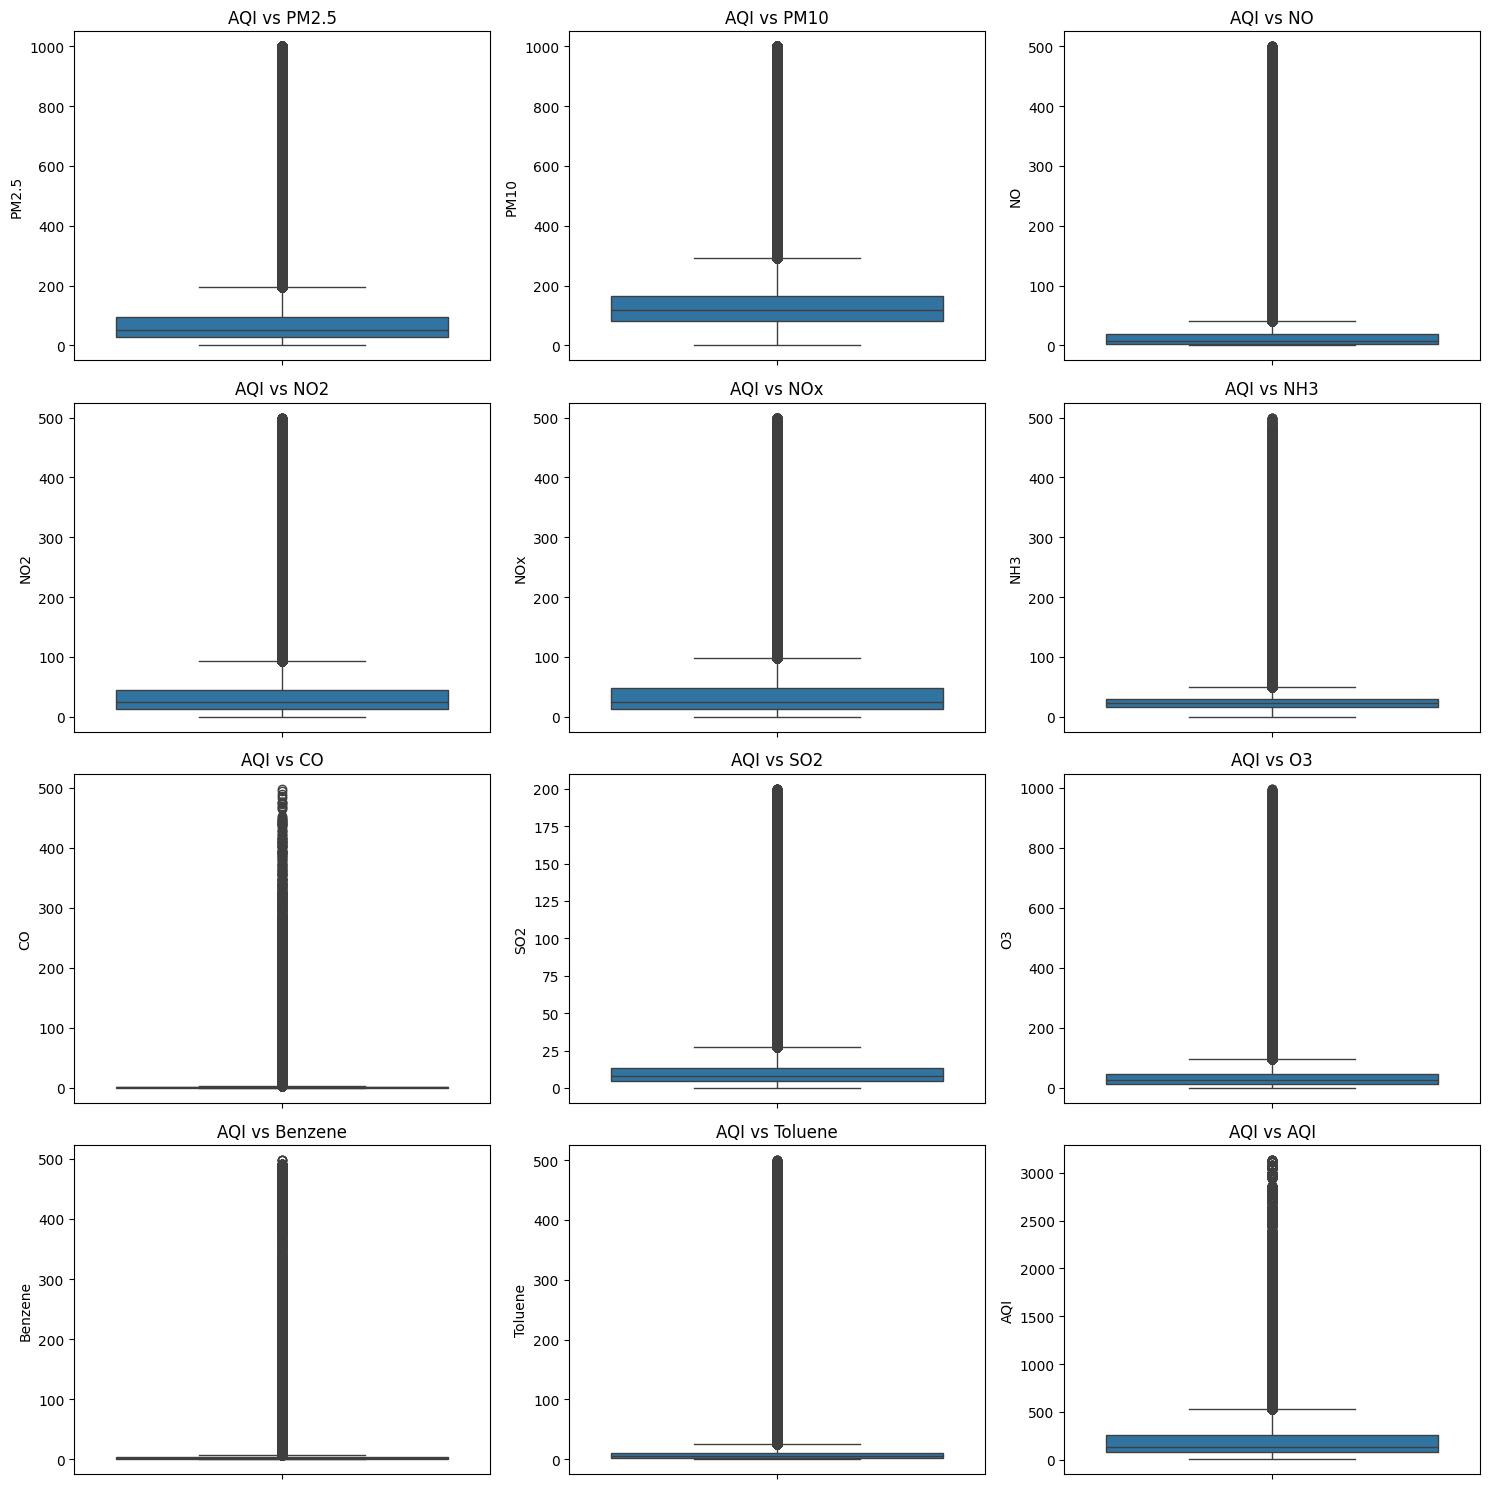

In [43]:
fig , ax = plt.subplots(4,3,figsize=(15,15))
for i , col in enumerate(pollutants):
    rows = i // 3
    cols = i % 3
    sns.boxplot(merged_df[col],ax=ax[rows,cols])
    ax[rows,cols].set_title(f"AQI vs {col}")

plt.tight_layout()
plt.show()

In [44]:
for col in pollutants:

    Q1 = merged_df[col].quantile(0.25)
    Q3 = merged_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    merged_df[col] = merged_df[col].clip(lower, upper)

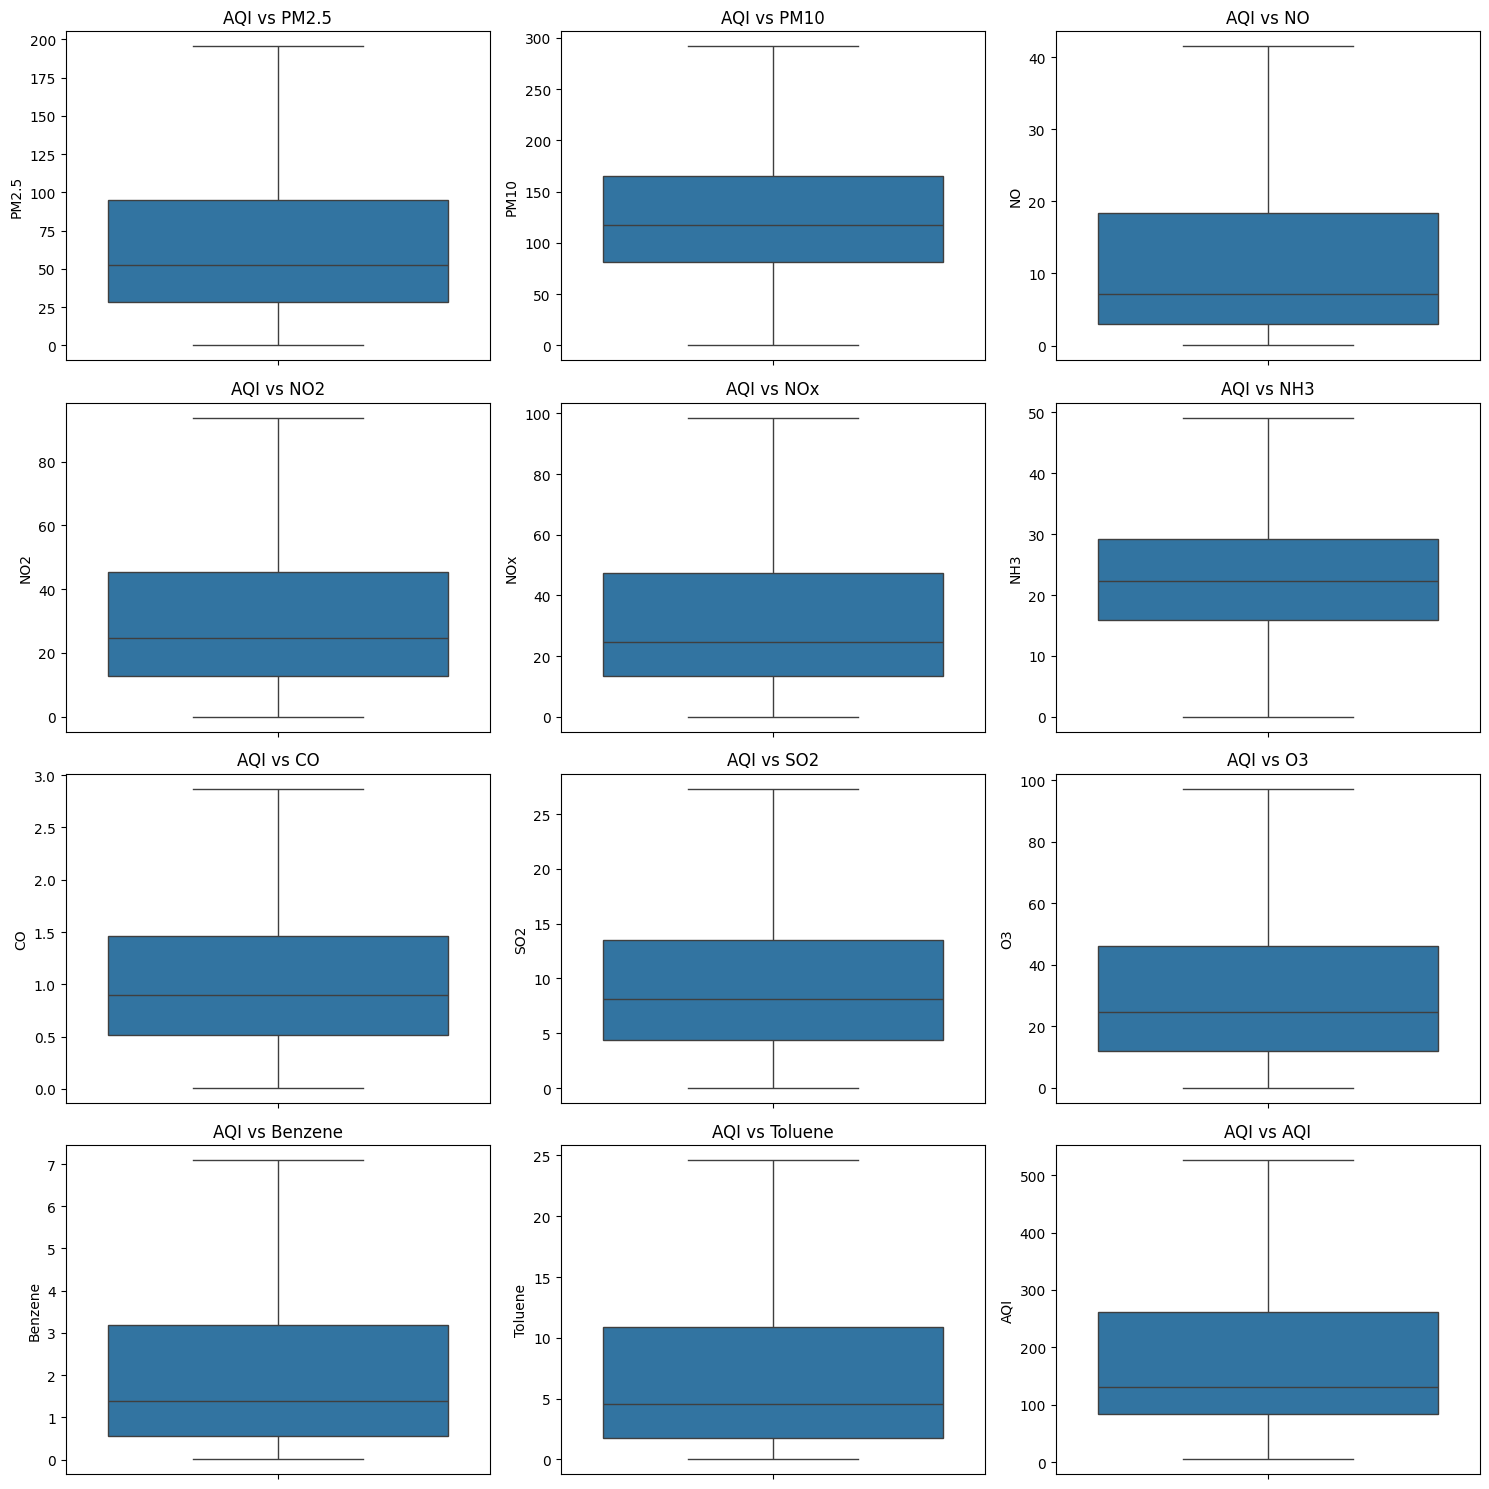

In [45]:
fig , ax = plt.subplots(4,3,figsize=(15,15))
for i , col in enumerate(pollutants):
    rows = i // 3
    cols = i % 3
    sns.boxplot(merged_df[col],ax=ax[rows,cols])
    ax[rows,cols].set_title(f"AQI vs {col}")

plt.tight_layout()
plt.show()

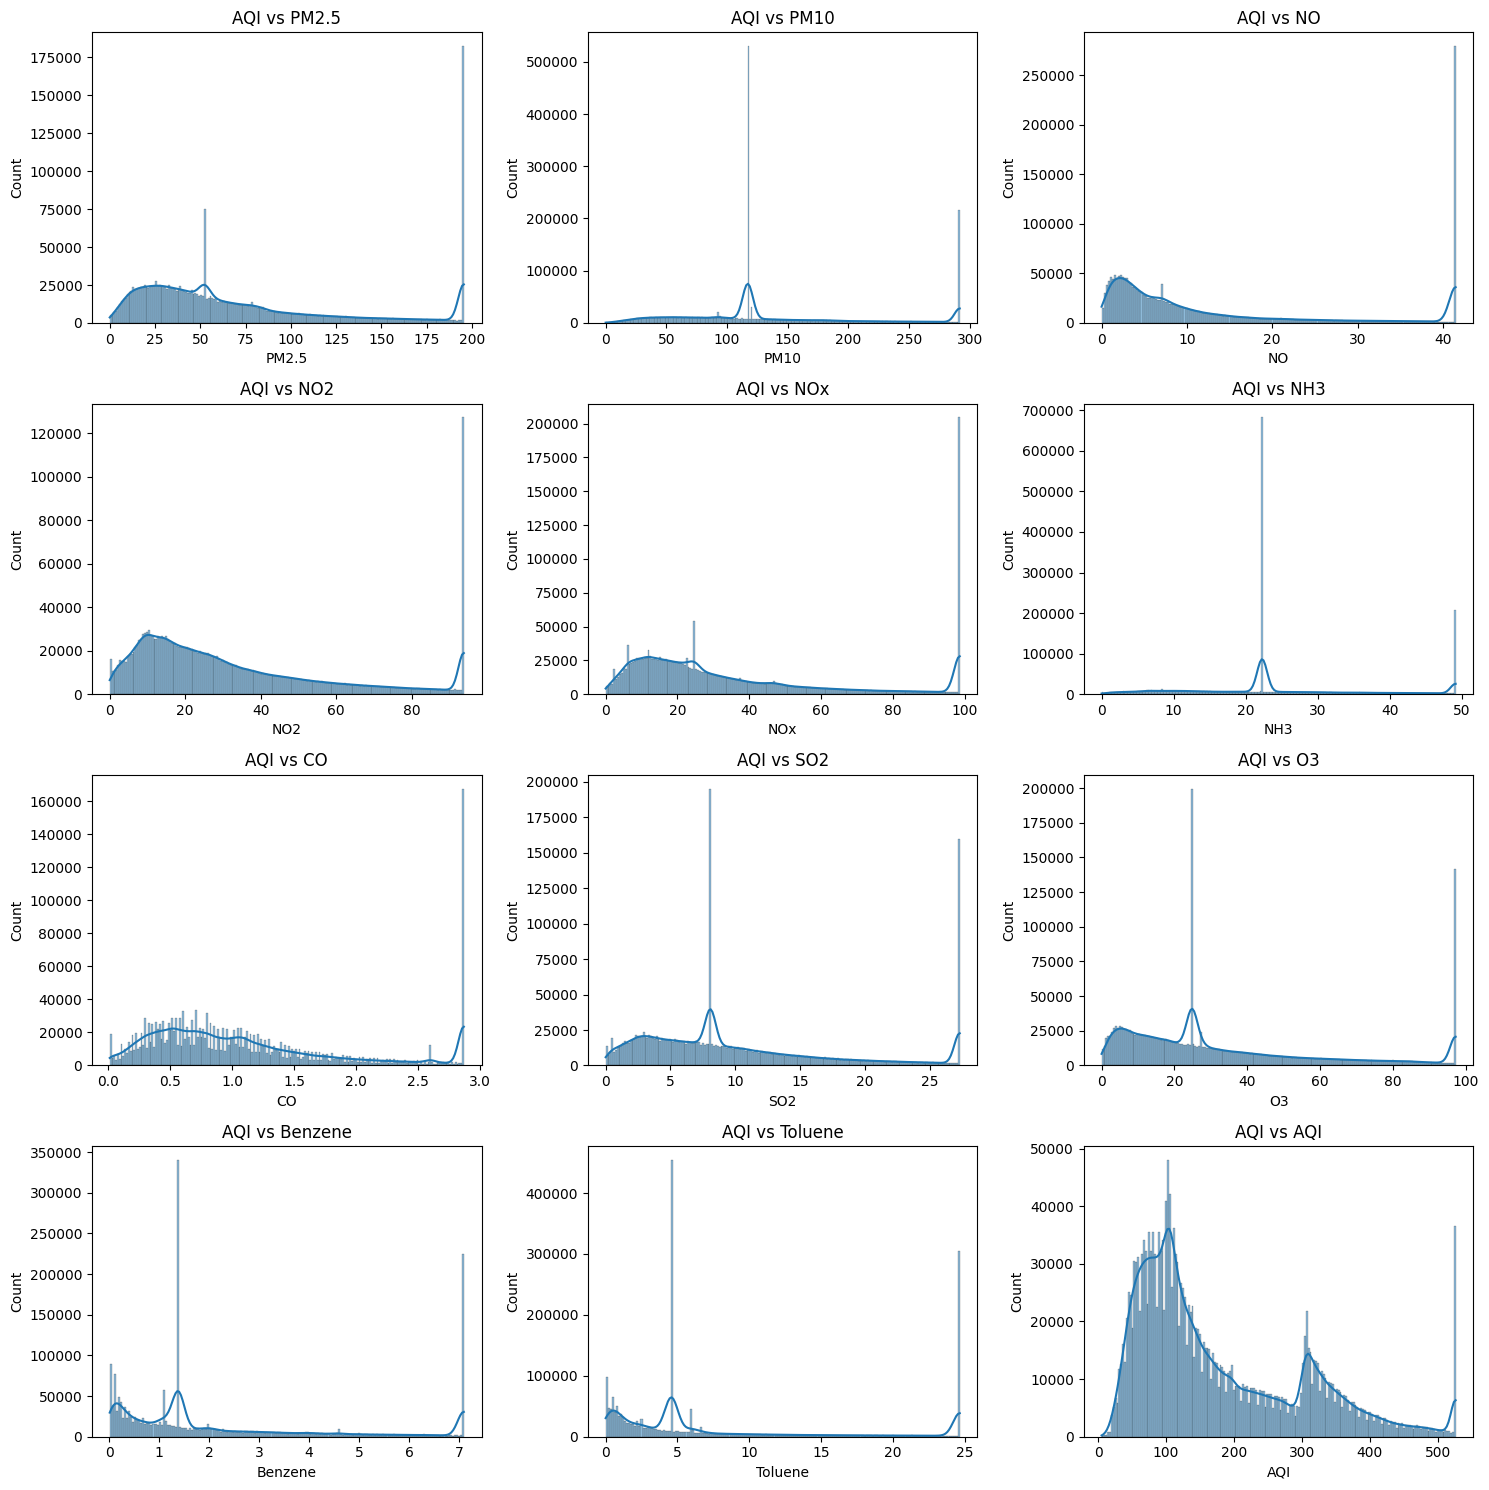

In [49]:
fig , ax = plt.subplots(4,3,figsize=(15,15))
for i , col in enumerate(pollutants):
    rows = i // 3
    cols = i % 3
    sns.histplot(merged_df[col],kde=True,ax=ax[rows,cols])
    ax[rows,cols].set_title(f"AQI vs {col}")
plt.tight_layout()
plt.show()

In [50]:
merged_df[pollutants].skew()

PM2.5      1.056855
PM10       0.796828
NO         1.161603
NO2        1.048914
NOx        1.097468
NH3        0.523945
CO         0.975820
SO2        0.998203
O3         1.059241
Benzene    1.158379
Toluene    1.145385
AQI        1.005021
dtype: float64

In [46]:
# merged_df['Day'] = merged_df['Datetime'].dt.day
# merged_df['Month'] = merged_df['Datetime'].dt.month
# merged_df['Year'] = merged_df['Datetime'].dt.year
# merged_df['Hour'] = merged_df['Datetime'].dt.hour
# merged_df['DayOfWeek'] = merged_df['Datetime'].dt.dayofweek
# merged_df['IsWeekend'] = merged_df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
# merged_df = merged_df.drop('Datetime', axis=1)
# merged_df.head()


In [47]:
# merged_df.shape

In [48]:
# merged_df[merged_df['Status'].isnull()]['AQI'].isnull().sum()